## Hopfield Networks

*Dev Shekhawat*

This notebook demonstrates my experiment with the Hopfield Networks. Named after the american computer scientist [John Hopfield](https://en.wikipedia.org/wiki/John_Hopfield) who won the 2024 physics nobel price for his research on the subject.

> Treat this notebook as an essay that I have written to solidify my understanding on Hopefield Networks and the physics behind it.

#### The biological connection (recalling memories)
Imagine walking through a busy city market on a weekend night. The street is abuzz with activity, but through the noise, you catch the faint sound of a piano drifting from a lively cafe. The melody instantly pulls you down memory lane—back to when your wife first discovered that song and wouldn't stop humming it, testing the absolute limits of your patience.

How did your brain do that? You only heard a fragment of an instrumental melody, yet you instantly recalled the lyrics, the context, and the emotion. Now, before you know it, you can't stop humming it yourself.

When a computer retrieves a memory, the CPU must know the data's exact physical address on the disk. Your brain, however, operates on a completely different architecture. It consists of nearly 86 billion neurons, none of which settle into a permanent, static state. Instead, they constantly activate and deactivate at rapid speeds through electrical bursts known as 'action potentials.' Unlike a hard drive, your brain does not store memories by permanently imprinting them onto a physical medium; the storage is dynamic. How do we model this biological architecture mathematically? We need a system where memories are not found by address, but by content—where a noisy, faint fragment (like that piano melody) is enough to reconstruct the whole. In computer science, this is known as Associative Memory or Content-Addressable Memory. To achieve this, physicist John Hopfield proposed a brilliant idea: he argued that we can treat memories not as data in a drawer, but as stable valleys on an energy surface.

![](./lab_files/energy_landscape.jpg)

### Valley of a memory
To model this architecture, let's define the memory as a vector consisting of neurons. For simplicity, we will talk about neurons with binary states. Each neuron can either be +1 or -1. Let's say we have $N$ neurons in a memory vector.This implies that the network can exist in $2^N$ possible unique states. For a small $32 \times 32$ pixel image, that is $2^{1024}$ possibilities—a number far larger than the atoms in the observable universe. Most of these states correspond to meaningless random noise. To find our specific memories in this vastness, Hopfield introduced an Energy Function. We configure the connections (weights) between neurons so that the specific patterns we want to store sit at the mathematical "bottom" of the energy landscape. These are the valleys—or basins of attraction.When we present the network with a corrupted or incomplete pattern, we are essentially placing a ball high up on the slopes of this terrain. The network's update dynamics act like gravity, naturally pulling the state down the steepest gradient until it settles into the nearest deep valley. The point where it stops—the stable, minimum-energy state—is the fully restored memory.

In essence, the Energy Function is the compass that guides the network. It assigns a 'score' to every possible configuration of neurons, creating a map where the lowest points (the valleys) are the stable memories we wish to retrieve. To calculate this energy, we need two things:

1. The Current State ($s$): This is the input pattern we are testing. It might be a perfect memory, total noise, or a partial fragment (like our piano melody).
2. The Weight Matrix ($W$): This is the architecture of the network itself. It is not a memory storage box, but a web of connections that encodes the relationships between all the memories simultaneously."

We will come back to the energy part later but first, let's understand how this Weight paramter is calculated.

In [118]:
import numpy as np

# Let's create two memory vectors. They will be binary vectors of size 10 witth values of +1 and -1.
memory1 = np.array([1, -1, 1, -1, 1, -1, 1, -1, 1, -1])
memory2 = np.array([1, 1, 1, 1, 1, -1, -1, -1, -1, -1])


#### Calculating the weights of the network
The core of the Hopfield network lies in its weights ($W$), which represent the connection strength between any two neurons, $i$ and $j$. In our binary network, where neurons take values of $+1$ or $-1$, the weight matrix is a square grid of size $N \times N$.We calculate these weights using a rule borrowed from neuroscience, famously summarized by Donald Hebb: "Neurons that fire together, wire together." Known as Hebbian Learning, this rule states that if two neurons activate simultaneously, their connection strengthens. In mathematical terms, the weight contribution is simply the product of the two neuron values:Agreement ($+1, +1$ or $-1, -1$): The product is positive ($+1$). The connection is strengthened (excitatory).Disagreement ($+1, -1$): The product is negative ($-1$). The connection is weakened (inhibitory).To calculate the weights for the entire network, we use the Outer Product. For a single memory vector $\mathbf{x}$, the weight matrix is $\mathbf{x}\mathbf{x}^T$. However, since we want to store multiple memories, we sum these matrices together. The final weight matrix $W$ becomes a superposition of all stored patterns:$$W = \frac{1}{N} \sum_{k=1}^{M} \mathbf{x}^{(k)} (\mathbf{x}^{(k)})^T$$(Note: We explicitly set the diagonal $W_{ii} = 0$, as neurons do not connect to themselves).This matrix $W$ serves as the physical archive of our memories. It encapsulates the statistical correlations of every pattern we have ever shown the network, allowing it to reconstruct the whole from a part.

In [119]:
Weights_A = np.outer(memory1, memory1)
Weights_B = np.outer(memory2, memory2)
np.fill_diagonal(Weights_A, 0)
np.fill_diagonal(Weights_B, 0)

Network_Weights = Weights_A + Weights_B
Network_Weights

array([[ 0,  0,  2,  0,  2, -2,  0, -2,  0, -2],
       [ 0,  0,  0,  2,  0,  0, -2,  0, -2,  0],
       [ 2,  0,  0,  0,  2, -2,  0, -2,  0, -2],
       [ 0,  2,  0,  0,  0,  0, -2,  0, -2,  0],
       [ 2,  0,  2,  0,  0, -2,  0, -2,  0, -2],
       [-2,  0, -2,  0, -2,  0,  0,  2,  0,  2],
       [ 0, -2,  0, -2,  0,  0,  0,  0,  2,  0],
       [-2,  0, -2,  0, -2,  2,  0,  0,  0,  2],
       [ 0, -2,  0, -2,  0,  0,  2,  0,  0,  0],
       [-2,  0, -2,  0, -2,  2,  0,  2,  0,  0]])

This is an abstract representation of the network with 8 neurons and 64 synapses (connections). Each connection will have a positive or negative weight. For connections with positive weight both neurons will have same activations.


![](./lab_files/weights_and_memory.jpg)

#### Defining the energy
Now that we have the weights, we can define the overall energy of the network. Remember, the value of energy is calculated for a specific state (configuration) of the network. We want to define our energy function in such a way that the energy is minimized for learned memory states and is significantly higher for random patterns.

- **Learned Memory:** The energy is low (the system is stable).
- **Noisy/Faint Pattern:** The energy is high (the system is unstable/under tension).

With this intuition, we can see how the overall energy landscape is a function of $N$ values, where $N$ is the number of neurons. In this high-dimensional landscape, if we stand at a random point, we are at the coordinates of either a stored memory (a valley), random noise (a peak), or somewhere in between.Mathematically, the energy $E$ of a state vector $\mathbf{s}$ is defined as:

$$E = -\frac{1}{2} \sum_{i,j} w_{ij} s_i s_j$$

Let's break down this formula to see why it works:

1. The Interaction ($W_{ij} s_i s_j$): This term checks for consistency. If two neurons have a positive weight ($W_{ij} > 0$) and they have the same sign ($s_i s_j > 0$), the result is a large positive number. This represents "Harmony."
2. The Negative Sign ($-$): Since we want "Harmony" to correspond to a valley (minimum), we flip the sign. High harmony becomes Low Energy (large negative number).
3. The Halving ($\frac{1}{2}$): Since the summation counts every pair twice (once for $i \to j$ and once for $j \to i$), we divide by 2 to get the true energy of the system.

If you feed the network a noisy version of a memory, the neurons will clash with the weights (disharmony). This results in a high energy value. The network will then naturally flip neurons to lower this energy, sliding down the landscape until it lands in the nearest memory valley.

In [120]:
# Function to calculate the energy of the network with respect to a given state
def calculate_network_energy(state, weights):
    return -0.5 * np.dot(state, np.dot(weights, state))

energy_A = calculate_network_energy(memory1, Network_Weights) # energy of memory A (stable)
energy_B = calculate_network_energy(memory2, Network_Weights) # energy of memory B (stable)

energy_unstable = calculate_network_energy(np.array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1]), Network_Weights) # energy of memory A (unstable)
energy_A, energy_B, energy_unstable # We see that energy of unstable state is higher than the energy of the memories. 

(np.float64(-42.0), np.float64(-42.0), np.float64(10.0))

#### How a noisy input makes the network retrieve a learned memory?

When you feed a noisy input (or a faint memory) to this network, the system effectively comes under "tension."

Remember that because of the weight matrix ($W$), every neuron "knows" what value it *should* have based on the behavior of the neighbors it is connected to. When you introduce a corrupted pattern, many neurons find themselves in states that contradict these learned constraints. This contradiction creates a high-energy, unstable state.

To restore balance and achieve a lower energy, the network initiates a repair process:

##### 1. Asynchronous Updates
The neurons do not update all at once. If every neuron tried to flip simultaneously based on the *current* state of its neighbors, the network could enter an infinite loop of oscillation (constantly flipping back and forth) without ever settling.

Instead, the update happens **asynchronously**—one neuron at a time. The network picks a neuron (randomly or sequentially) and allows it to "decide" its new state. In essence, the neuron does not care about the network as a whole; it only cares about satisfying the local constraints imposed by the weight matrix.

##### 2. The Local "Vote" (The Update Rule)
Since the neuron acts selfishly to satisfy its direct connections, it performs a simple "weighted vote."

Mathematically, a neuron $s_i$ looks at all its neighbors ($s_j$) and calculates a weighted sum to decide its new state:

$$s_i \leftarrow \text{sign}\left(\sum_{j} w_{ij} s_j\right)$$

* **If the sum is positive:** The consensus of the weighted connections says this neuron should be **ON (+1)**.
* **If the sum is negative:** The consensus says it should be **OFF (-1)**.
* **The Flip:** The neuron immediately flips its state to match this consensus.

Intuitively, think of this as **peer pressure**. If your "friends" (positive weights) are active, they drag you up to +1. If your "enemies" (negative weights) are active, they push you down to -1.

##### 3. The Energy Slide (Global Consequence)
Here is where the physics of the Hopfield Network comes in. Even though the neuron made a local decision just to satisfy its neighbors, **it inadvertently lowered the energy of the entire system.**

The "Energy" ($E$) of the network is defined by the amount of "conflict" between neurons:

$$E = -\frac{1}{2} \sum_{i,j} w_{ij} s_i s_j$$

Every time a neuron updates itself to match its neighbors (Step 2), it resolves a local conflict. Mathematically, this guarantees that the Global Energy $E$ decreases (or stays the same). It **never** goes up.

##### 4. Convergence
Because the energy drops with every single flip, the system acts like a ball rolling down a rough hill. It cannot roll forever. Eventually, it must hit a valley—a local minimum.

* When the network reaches this state, every neuron is perfectly aligned with the constraints of its neighbors.
* If any neuron checks its input sum again, it sees that it is already in the correct state. No more flips occur.
* The system freezes.

This "frozen" state is the **Attractor**. Because we constructed the weight matrix using Hebbian learning, this valley corresponds exactly to the **original, clean memory**. The noise has been "shaken out" of the system, and the memory is retrieved.

![](./lab_files/tension.png)

In [121]:
# Let's see how the network converges to the memory A given a noisy input that is close to memory A.

# Let's create a noisy input that is close to memory A.
noisy_input = np.array([1, -1, 1, -1, 1, -1, 1, 1, 1, 1])

# Let's update the state based on update rule.
new_state = np.sign(np.dot(Network_Weights, noisy_input))
print(new_state == memory1) # We see that the network converges to memory A.

# For inputs with higher dimensions and more noise we update the state multiple times by selecting a random neuron to update.

[ True  True  True  True  True  True  True  True  True  True]


#### The "Ghost" Memories (Spurious States)

While the Hopfield Network is powerful, it has a haunting side effect. Sometimes, the network converges to a stable state that you **never taught it**. These are called **Spurious States** (or "Ghost Memories").

In our energy landscape analogy, these are "accidental valleys"—places where the ball gets stuck, even though you never dug a hole there.

There are two main types of ghosts in the machine:

##### 1. The "Anti-Memory" (Symmetry)
If the network learns a pattern (e.g., an image of a black circle on white), it *automatically* learns the exact inverse (a white circle on black).

**The Math:**
Look at the energy equation again:
$$E = -\frac{1}{2} \sum_{i,j} w_{ij} s_i s_j$$

If you flip the sign of *every* neuron (change every $+1$ to $-1$ and every $-1$ to $+1$), the product $s_i s_j$ remains exactly the same:
$$(-s_i) \times (-s_j) = s_i s_j$$

Because the energy value doesn't change, the "Anti-Memory" has the exact same depth as the original memory. It is a mathematical mirror image.

##### 2. The "Frankenstein" Memory (Mixture States)
If you teach the network too many patterns, the valleys in the landscape start to interfere with each other.

Imagine you teach it a "Dog" and a "Cat." Ideally, these are two distinct valleys separated by a hill. But if the patterns share too many active neurons (correlation), the valleys might merge. The network might settle in a shallow valley right in the middle—a stable state that looks like a weird, logical mixture of both patterns.

![](./lab_files/ghosts.png)

* **Why it happens:** The network is trying to satisfy the constraints of Pattern A *and* Pattern B simultaneously, getting stuck in a local minimum where it partially satisfies both but fully satisfies neither.

#### Overcoming the limits
This concept of energy landscape and the method of retrieving memories was descriped in Hopfields 1982 paper [Neural networks and physical systems with emergent collective computational abilities.](https://www.pnas.org/doi/10.1073/pnas.79.8.2554) As we saw this model has limits for the number of memories that can be learned.

In 2020, John Hopfield published another paper [LARGE ASSOCIATIVE MEMORY PROBLEM IN NEUROBIOLOGY AND MACHINE LEARNING](https://arxiv.org/pdf/2008.06996) where he proposed a ground breaking solution that exponentially increased the memory limit. We call it a Modern Hopfield Network

### Let's use this simple hopfield network to store some complex memories

In [122]:
# Necessary imports
import numpy as np
import matplotlib.pyplot as plt

We create a class `SimpleHopfieldRestoration` to track the restoration process

In [123]:
import matplotlib.gridspec as gridspec
from utils import get_accuracy

# The state of the network for a given memory
class State:
  value: np.ndarray # Value of the memory vector
  energy: float # Energy of the network for the given memory vector
  accuracy: float # Accuracy of the network for the given memory vector with respect to the original memory
  def __init__(self, value: np.ndarray, energy: float, accuracy: float):
    self.value = value
    self.energy = energy
    self.accuracy = accuracy

# The entity to track the restoration process
class SimpleHopefieldRestoration:
  def __init__(self, W: np.ndarray, original_state: np.ndarray, input_state: np.ndarray):
    self.W = W # Weight matrix of the network
    self.original_state = original_state # Original memory
    self.states = [] # List to store the state of the network for each iteration
    # We initialize the state of the network with the input state
    self.states.append(State(
      input_state.copy(),
      self.calculate_energy(input_state.copy()),
      get_accuracy(original_state, input_state.copy()))
    )

  def calculate_energy(self, state: np.ndarray):
    """Calculate the energy of the network for a given state"""
    return -0.5 * np.dot(state, np.dot(self.W, state))

  def add_state(self, state: np.ndarray):
    """Add a new state to the restoration process"""
    self.states.append(State(
      state.copy(),
      self.calculate_energy(state.copy()),
      get_accuracy(self.original_state, state.copy()))
    )

  def plot_restoration(self):
    """Plot the restoration process"""
    num_states = len(self.states)
    fig = plt.figure(figsize=(20, 15))
    gs = gridspec.GridSpec(3, 4, height_ratios=[2, 2, 1])

    img_shape = int(np.sqrt(self.original_state.shape[0]))

    # Row 1: 4 images
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_title("Original Image")
    ax1.imshow(self.original_state.reshape(img_shape, img_shape), cmap="plasma")
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_title("Input")
    ax2.imshow(self.states[0].value.reshape(img_shape, img_shape), cmap="plasma")
    ax2.axis('off')

    ax3 = fig.add_subplot(gs[0, 2])
    early_idx = int(num_states // 3)
    ax3.set_title("Early Recall")
    ax3.imshow(self.states[early_idx].value.reshape(img_shape, img_shape), cmap="plasma")
    ax3.axis('off')

    ax4 = fig.add_subplot(gs[0, 3])
    late_idx = int(2 * num_states // 3)
    ax4.set_title("Late Recall")
    ax4.imshow(self.states[late_idx].value.reshape(img_shape, img_shape), cmap="plasma")
    ax4.axis('off')

    # Row 2: Restored image, Final energy/accuracy text
    ax5 = fig.add_subplot(gs[1, 0:2])
    ax5.set_title("Restored Image")
    ax5.imshow(self.states[-1].value.reshape(img_shape, img_shape), cmap="plasma")
    ax5.axis('off')

    ax6 = fig.add_subplot(gs[1, 2:4])
    ax6.axis('off')
    final_energy = self.states[-1].energy
    final_accuracy = self.states[-1].accuracy
    ax6.text(0.5, 0.7, f"Final Energy:\n{final_energy:.2f}", ha='center', va='center', fontsize=26, weight='bold', color='darkblue', transform=ax6.transAxes)
    ax6.text(0.5, 0.3, f"Final Accuracy:\n{final_accuracy*100:.2f}%", ha='center', va='center', fontsize=26, weight='bold', color='darkgreen', transform=ax6.transAxes)

    # Row 3: Energies and Accuracies
    ax7 = fig.add_subplot(gs[2, 0:2])
    energies = [state.energy for state in self.states]
    ax7.plot(energies, marker='o', color='purple')
    ax7.set_title("Energy Across Iterations")
    ax7.set_xlabel("Iteration")
    ax7.set_ylabel("Energy")

    ax8 = fig.add_subplot(gs[2, 2:4])
    accuracies = [state.accuracy for state in self.states]
    ax8.plot([a * 100 for a in accuracies], marker='o', color='teal')
    ax8.set_title("Accuracy Across Iterations")
    ax8.set_xlabel("Iteration")
    ax8.set_ylabel("Accuracy (%)")

    plt.tight_layout()
    plt.show()

Next, let's create a `SimpleHopfieldNetwork` that will be trained on a set of memories. We will train it to store 2-dimensional binary images of +1s and -1s

In [124]:
from utils import get_accuracy
from BaseNetwork import BaseNetwork
from SimpleHopefieldRestoration import SimpleHopefieldRestoration

class SimpleHopfieldNetwork(BaseNetwork):
    """
    A simple NxN Hopfield network
    """
    def __init__(self, size):
        self.size = size #Size of one side of the image
        self.n = size * size #Total number of neurons in the network
        self.W = np.zeros((self.n, self.n)) #Weight matrix of the network

    def train(self, patterns):
        """Train the network on a set of memories i.e. create a weight matrix"""
        print(f"Learning {len(patterns)} memories with {self.n} neurons...")
        print(f"Synaptic Connections: {self.n**2:,} weights.")
        for p in patterns:
            self.W += np.outer(p, p)
        np.fill_diagonal(self.W, 0)
        # We normalize the weights to keep the field values manageable
        self.W /= self.n 
        return self.W

    def energy(self, state):
        """
        Calculates the energy of the network for a given state
        """
        return -0.5 * np.dot(state, np.dot(self.W, state))

    def get_field_map(self, state):
        """
        Returns the 'Pressure' map (What the neurons want to do)
        For an entry at (i,j) the field vector tells us how much the neuron at (i,j) wants to be 1 or -1.
        """
        return np.dot(self.W, state)

    def restore_memory(self, input_state, original_state, steps=50):
        """Restore a memory from a noisy input"""
        # Initialize the restoration process
        restoration = SimpleHopefieldRestoration(self.W, original_state, input_state)
        # Iterate over the number of steps. in each step we select a random neuron and update its value based on the field vector.
        # We do it step*n times to ensure that the network has time to explore the state space.
        for i in range(steps*self.n):
            # Select a random neuron
            idx = np.random.randint(self.n)
            # copy over the previous state
            new_value = restoration.states[-1].value.copy()
            # calculate the field vector for the selected neuron
            field = np.dot(self.W[idx], new_value)
            # update the value of the selected neuron
            new_value[idx] = 1 if field >= 0 else -1
            # add the new state to the restoration process
            restoration.add_state(new_value)
        return restoration

In [125]:
SIZE = 32 # Size of the image
M = 3 # Number of memories to store

We will now import some arts which are 32x32 matrix of +1s and -1s

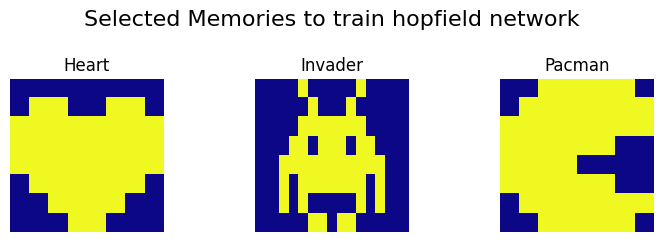

In [126]:
import art
from utils import plot_selected_arts

arts, names = art.create_arts() # Returns a list a tuple of (art, name)
selected_arts = arts[:M] # Select the first M arts

names = [name for _, name in selected_arts] # Extract the names of the selected arts
selected_arts = [art for art, _ in selected_arts] # Extract the arts from the selected tuple
plot_selected_arts(selected_arts, names)

In [127]:
# Create a simple hopfield network and train it on the selected arts

net = SimpleHopfieldNetwork(SIZE)
memory_matrix = net.train(selected_arts)

Learning 3 memories with 1024 neurons...
Synaptic Connections: 1,048,576 weights.


We will now pick a random image from the selected images and add some noise to it

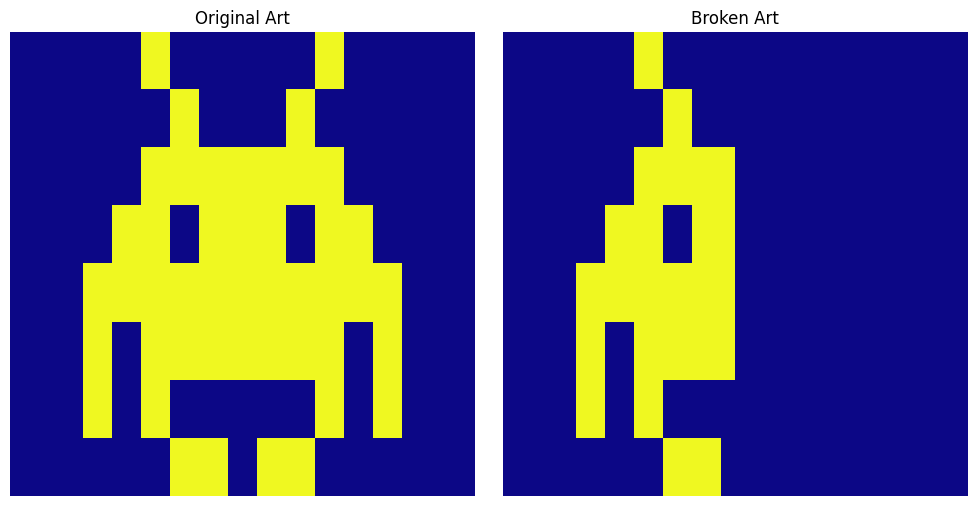

In [128]:
from utils import break_art_and_flattern

random_art = selected_arts[np.random.randint(len(selected_arts))]
random_art_broken = break_art_and_flattern(random_art)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Art")
plt.imshow(random_art.reshape(SIZE, SIZE), cmap='plasma', vmin=-1, vmax=1)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Broken Art")
plt.imshow(random_art_broken.reshape(SIZE, SIZE), cmap='plasma', vmin=-1, vmax=1)
plt.axis('off')

plt.tight_layout()
plt.show()


Let's see how our attempt to retore this broken memory into a complete one goes.

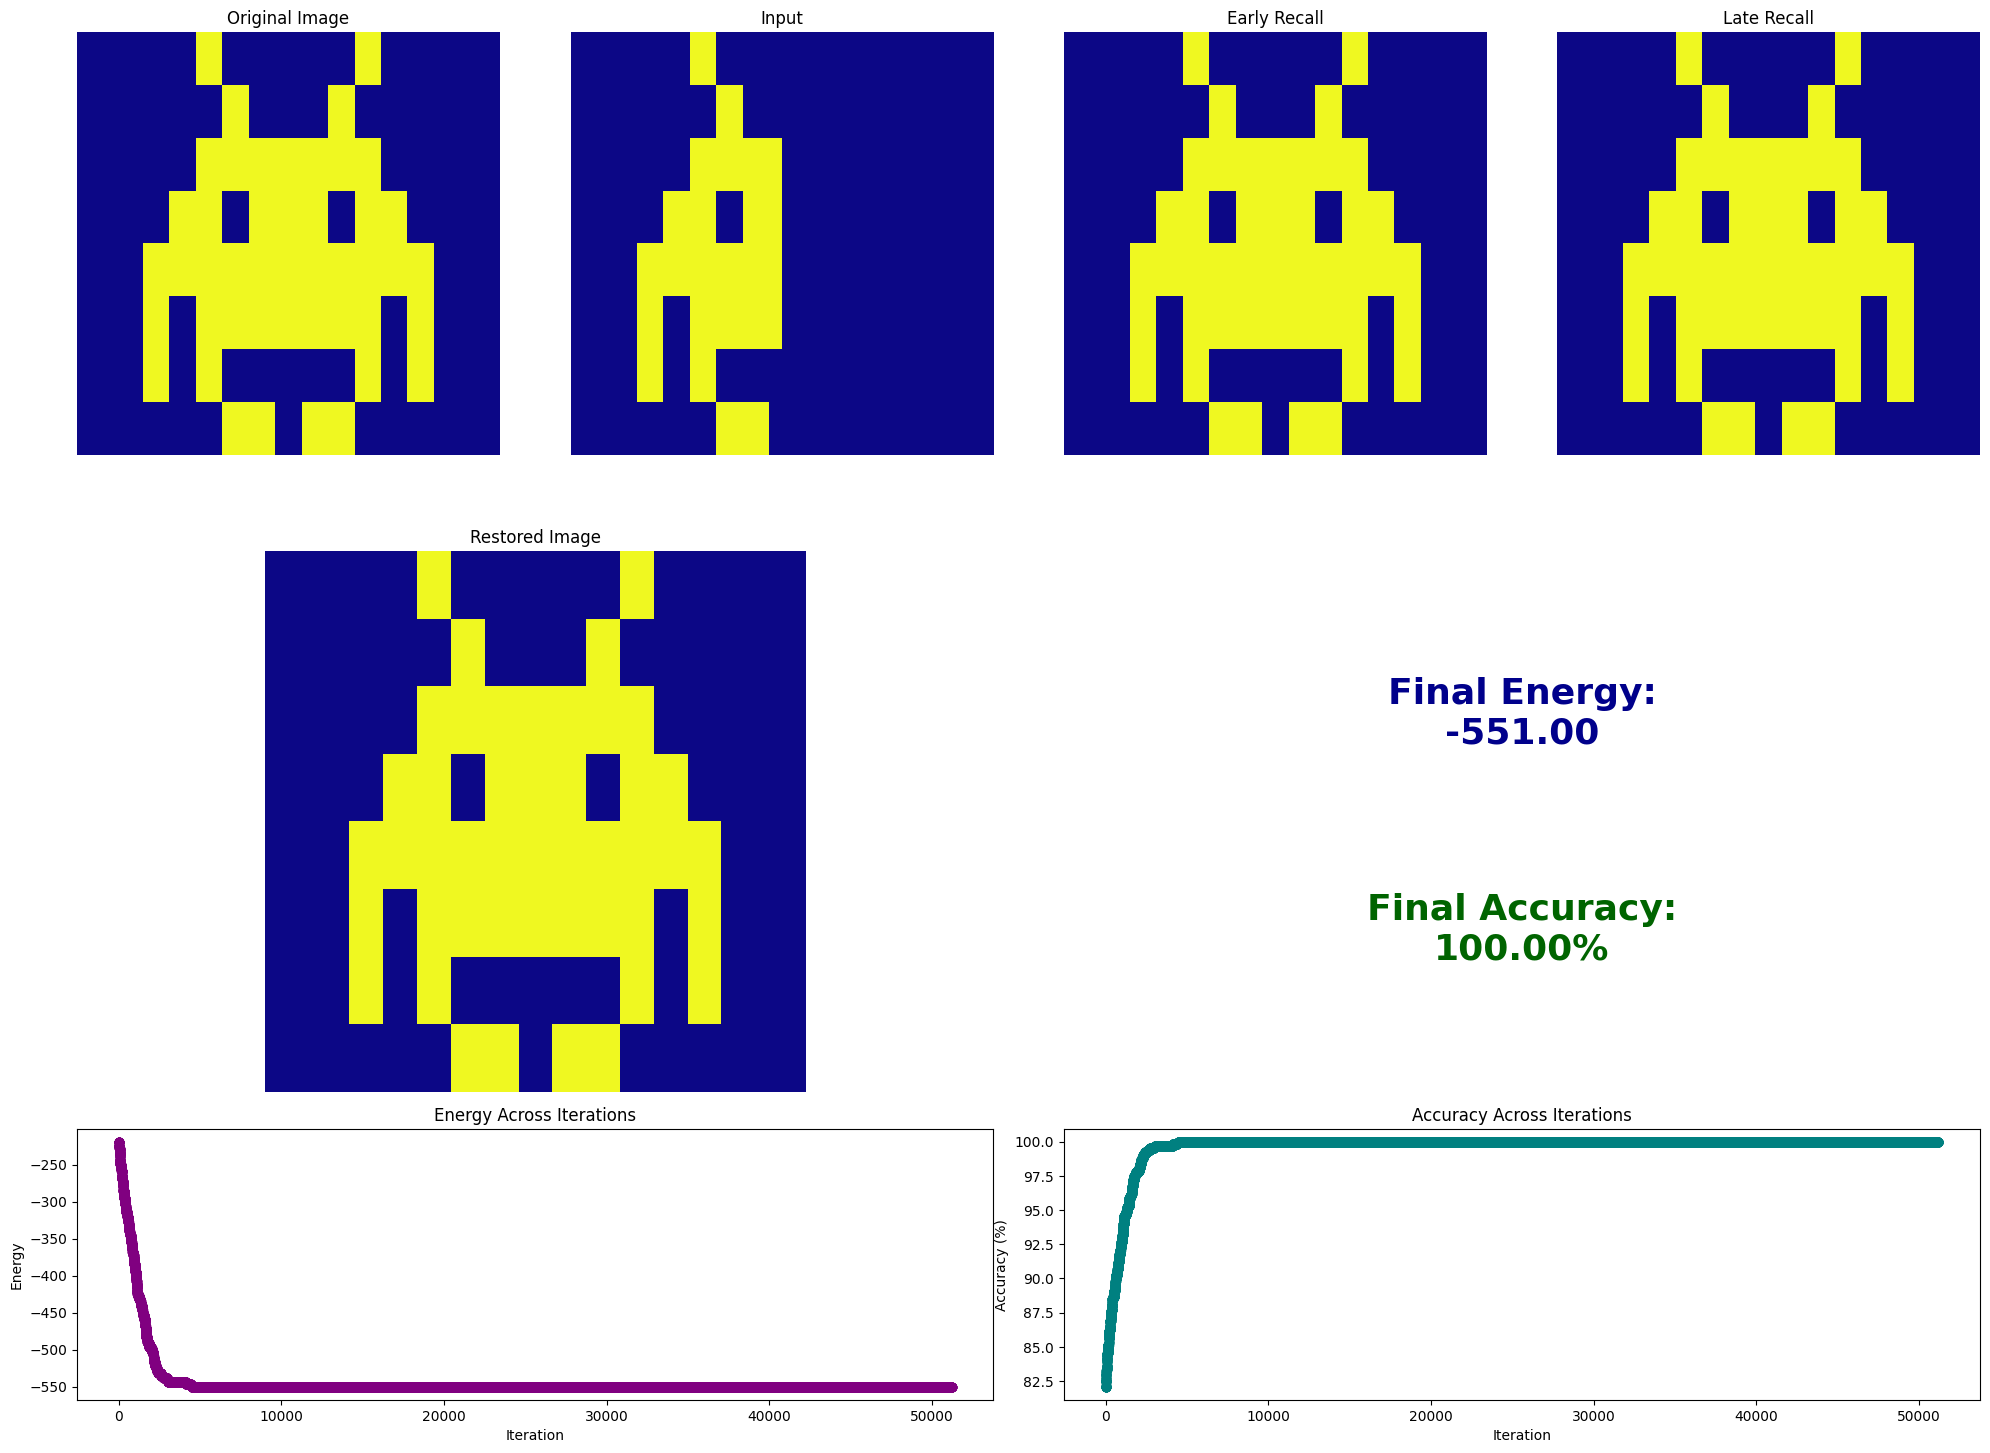

In [129]:
restoration = net.restore_memory(random_art_broken, random_art)
restoration.plot_restoration()


#### A ghost!
This happened because most of our images share a lot in common. it's either mostly background or mostly foreground. Even though we acheived a lower energy, because of the simmilarities in the original set of memories, the valleys in the energy landscape lies so closer to each other that there are some hidden valleys where ghost memories, a mixture of memories live.

### Let's try with random static patterns
We try with random patterns to see if the randomness eliminates the closeness of the memory vectors

In [130]:
random_static_images = art.get_random_binary_images(SIZE, 10) # We get 10 random static patterns
net = SimpleHopfieldNetwork(SIZE)
memory_matrix = net.train(random_static_images)

Learning 10 memories with 1024 neurons...
Synaptic Connections: 1,048,576 weights.


In [131]:
memory_matrix.shape

(1024, 1024)

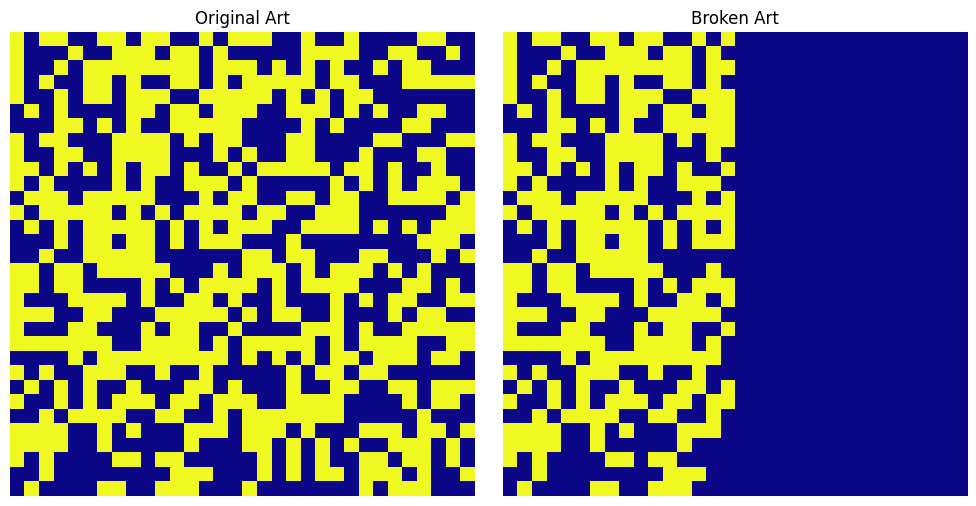

In [132]:
# Select a random image from the set of random static images
random_static_image = random_static_images[np.random.randint(len(random_static_images))]
# Break the image and flatten it
random_static_image_broken = break_art_and_flattern(random_static_image)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Art")
plt.imshow(random_static_image.reshape(SIZE, SIZE), cmap='plasma', vmin=-1, vmax=1)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Broken Art")
plt.imshow(random_static_image_broken.reshape(SIZE, SIZE), cmap='plasma', vmin=-1, vmax=1)
plt.axis('off')

plt.tight_layout()
plt.show()

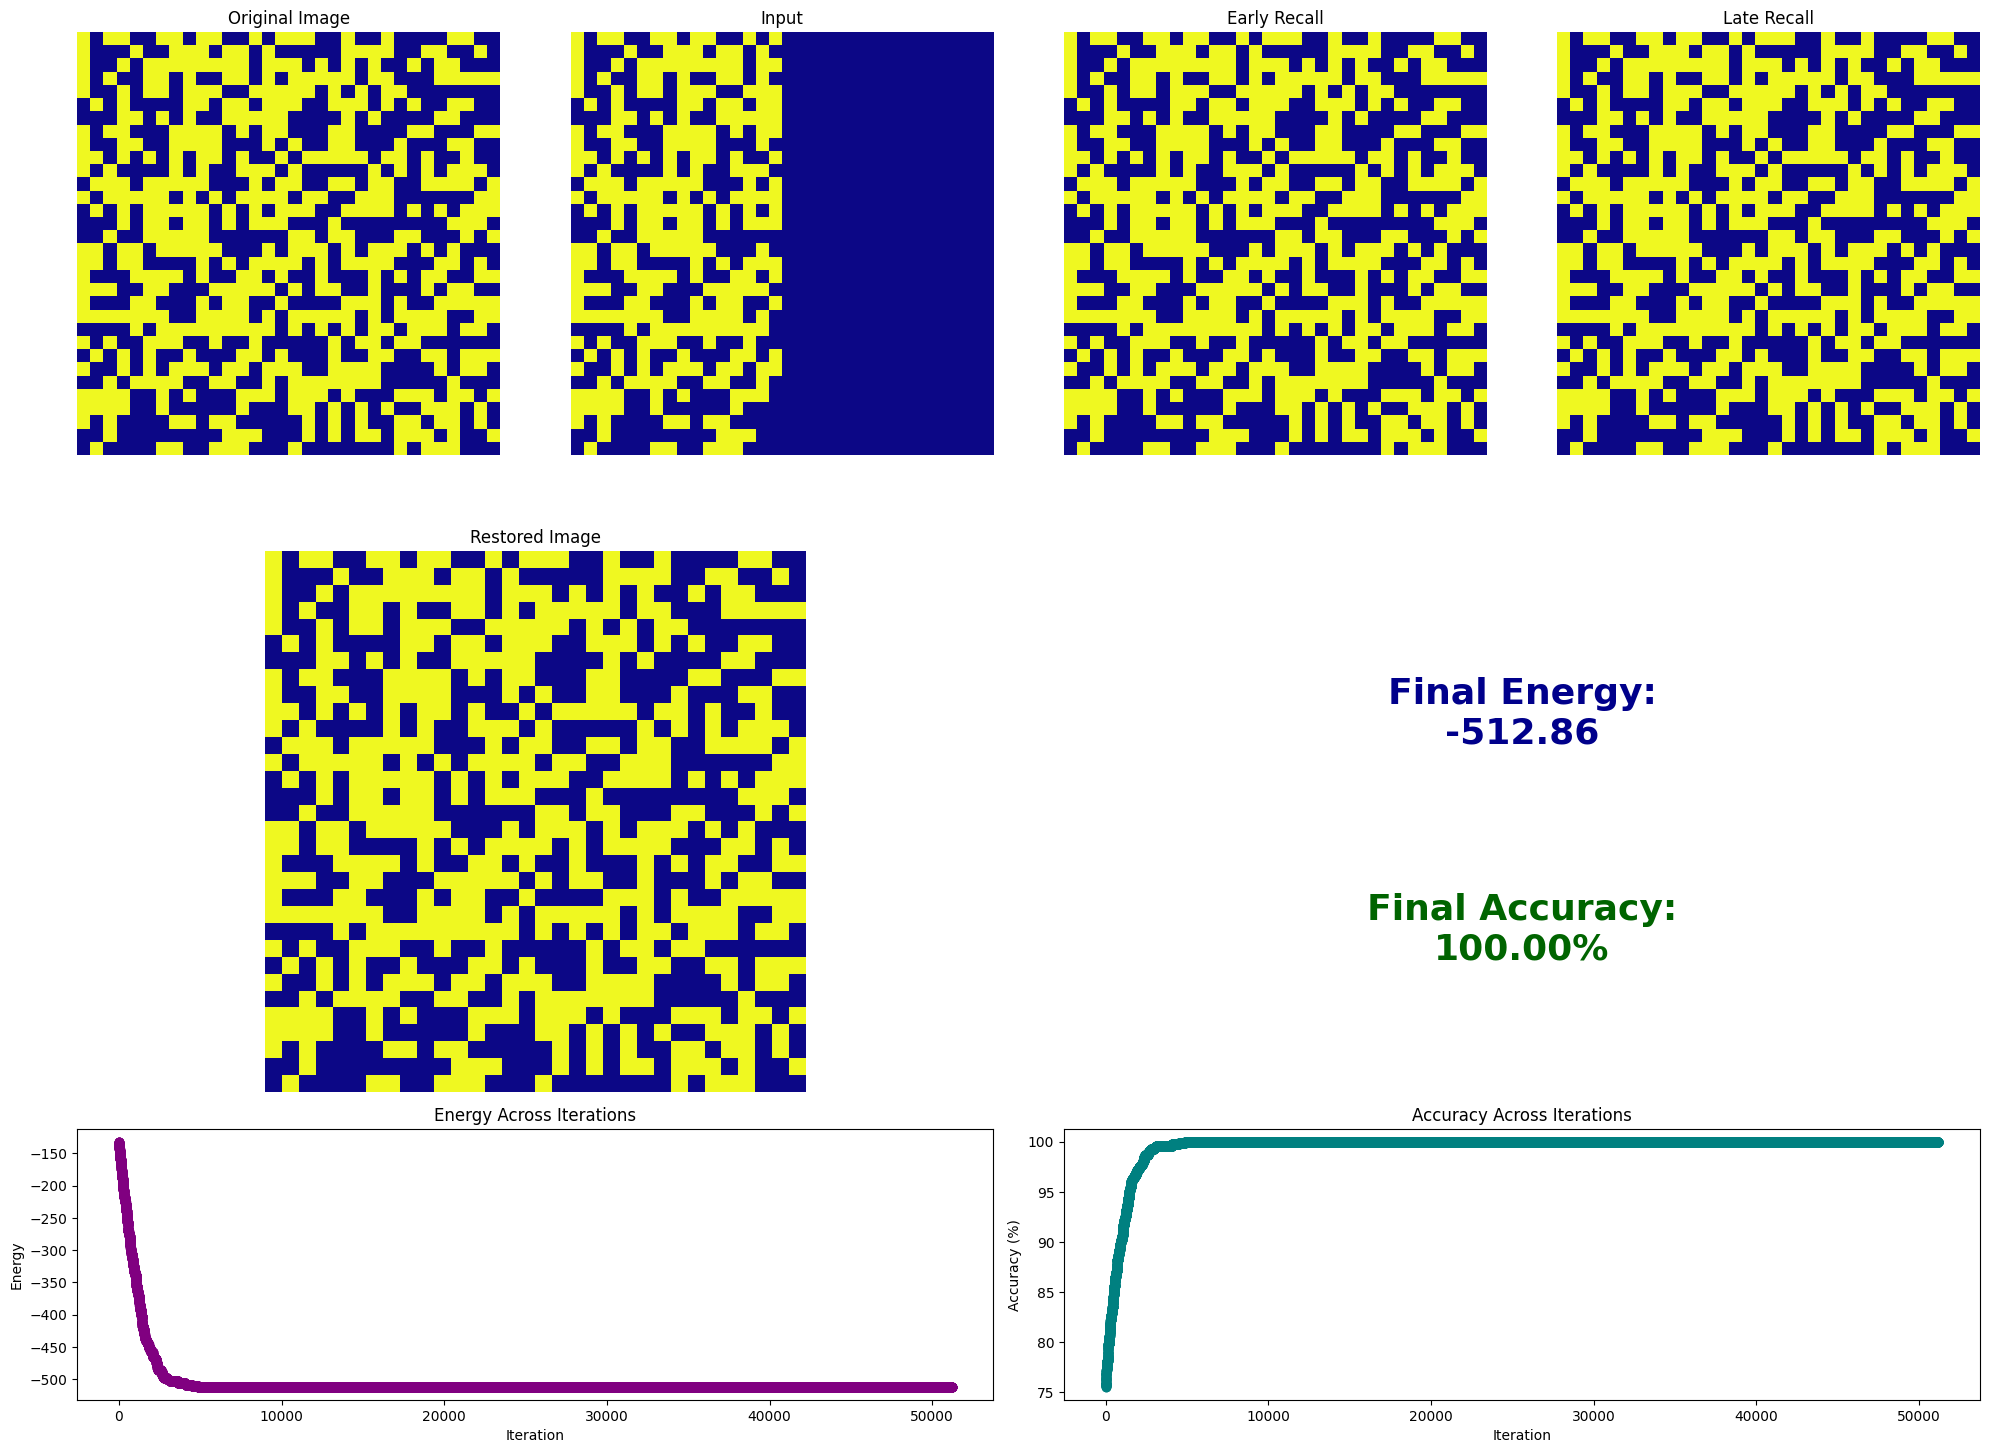

In [133]:
restoration = net.restore_memory(random_static_image_broken, random_static_image)
restoration.plot_restoration()


### A 100% accuracy

#### The Capacity Limit
These ghosts become much more frequent if you overload the network. A standard Hopfield network has a severe storage limit.

* **The Rule of Thumb:** You can only store approximately **0.14N** patterns (where N is the number of neurons) before the "ghosts" take over and the system loses its ability to recall anything correctly. How we came to this number is out of scope for this essay but remember that it is not a magic number, but derived from the rules of statistics.
* For a 100-neuron network, you can only safely store about 14 distinct memories. Beyond that, the energy landscape becomes too rugged, full of false valleys and confusion.